In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 加载数据
data_path = '../data/train/2.npz'
data = np.load(data_path)

print("=" * 50)
print("NPZ文件包含的键:")
print("=" * 50)
for key in data.keys():
    print(f"  - {key}")

NPZ文件包含的键:
  - xs
  - xs_gn
  - TR
  - ys


In [2]:
# 详细查看每个数组的属性
print("=" * 60)
print("各数组的详细信息:")
print("=" * 60)

for key in data.keys():
    arr = data[key]
    print(f"\n【{key}】")
    print(f"  Shape: {arr.shape}")
    print(f"  Dtype: {arr.dtype}")
    print(f"  Min: {arr.min():.6f}")
    print(f"  Max: {arr.max():.6f}")
    print(f"  Mean: {arr.mean():.6f}")
    print(f"  Std: {arr.std():.6f}")

各数组的详细信息:

【xs】
  Shape: (128, 128)
  Dtype: float32
  Min: -0.990000
  Max: 0.000000
  Mean: -0.057079
  Std: 0.219669

【xs_gn】
  Shape: (128, 128)
  Dtype: float32
  Min: -1.100699
  Max: 0.410935
  Mean: -0.065326
  Std: 0.222035

【TR】
  Shape: (128, 128)
  Dtype: float32
  Min: -4.121119
  Max: 2.639423
  Mean: -0.250788
  Std: 0.809338

【ys】
  Shape: (208, 1)
  Dtype: float32
  Min: -0.000015
  Max: 0.000088
  Mean: 0.000006
  Std: 0.000015


In [3]:
# 提取各个数组
xs = data['xs']       # (128, 128)
xs_gn = data['xs_gn'] # (128, 128)
TR = data['TR']       # (128, 128)
ys = data['ys']       # (208, 1)

print("数据已加载到变量:")
print(f"  xs: {xs.shape} - 可能是重建图像或输入特征")
print(f"  xs_gn: {xs_gn.shape} - 可能是Gauss-Newton重建结果")
print(f"  TR: {xs.shape} - 可能是真实值(Ground Truth)或掩码")
print(f"  ys: {ys.shape} - 可能是测量数据(208个测量值)")

数据已加载到变量:
  xs: (128, 128) - 可能是重建图像或输入特征
  xs_gn: (128, 128) - 可能是Gauss-Newton重建结果
  TR: (128, 128) - 可能是真实值(Ground Truth)或掩码
  ys: (208, 1) - 可能是测量数据(208个测量值)


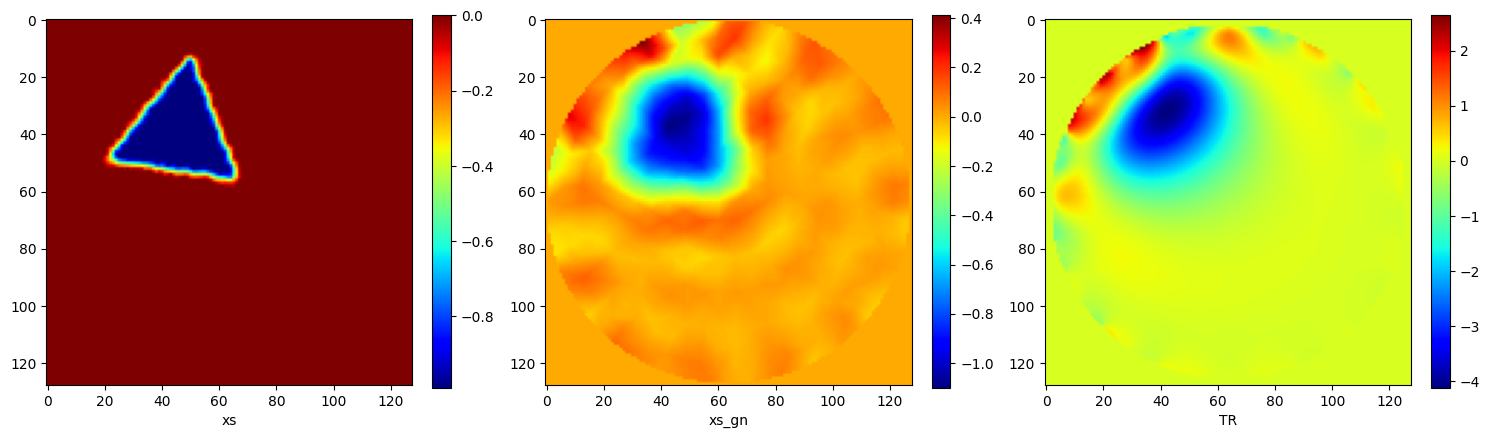

In [4]:
# 可视化128x128的图像数据
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# xs
im0 = axes[0].imshow(xs, cmap='jet')
axes[0].set_xlabel('xs')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# xs_gn
im1 = axes[1].imshow(xs_gn, cmap='jet')
axes[1].set_xlabel('xs_gn')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# TR
im2 = axes[2].imshow(TR, cmap='jet')
axes[2].set_xlabel('TR')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

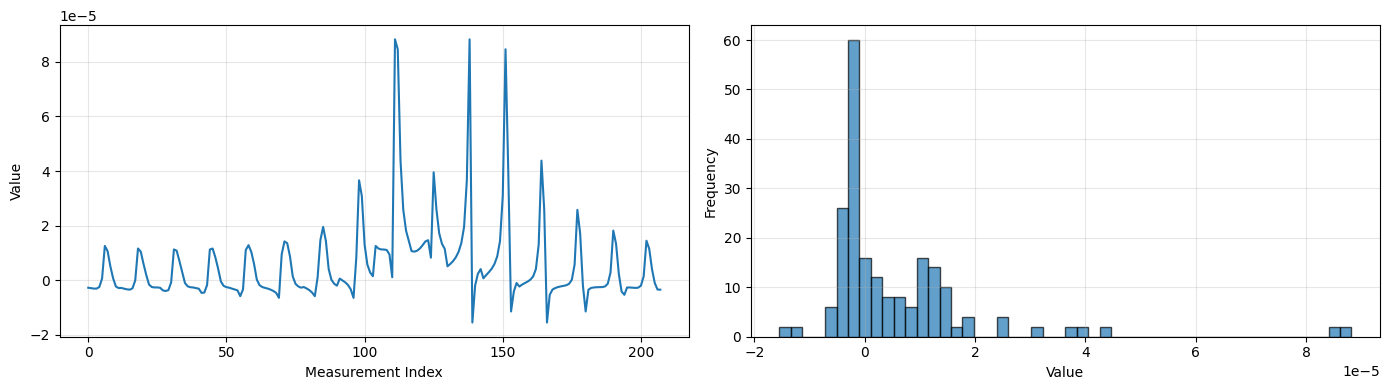

In [5]:
# 可视化ys测量数据
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 线图
axes[0].plot(ys.flatten())
axes[0].set_xlabel('Measurement Index')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# 直方图
axes[1].hist(ys.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# 分析TR数组的唯一值（判断是否为掩码或分割图）
unique_values = np.unique(TR)
print(f"TR数组的唯一值数量: {len(unique_values)}")
if len(unique_values) <= 20:
    print(f"唯一值: {unique_values}")
else:
    print(f"前10个唯一值: {unique_values[:10]}")
    print(f"后10个唯一值: {unique_values[-10:]}")

TR数组的唯一值数量: 12001
前10个唯一值: [-4.121119  -4.118452  -4.1155767 -4.1147604 -4.111462  -4.104401
 -4.104348  -4.0996375 -4.0946093 -4.0918756]
后10个唯一值: [2.2921505 2.3130357 2.3130674 2.330096  2.3696854 2.3900313 2.4802792
 2.5120273 2.5341847 2.6394227]


In [7]:
# 查看其他训练样本，确认数据结构一致性
import os

train_dir = '../data/train'
train_files = sorted([f for f in os.listdir(train_dir) if f.endswith('.npz')])[:5]

print(f"检查前5个训练文件的结构一致性:")
print("=" * 60)

for fname in train_files:
    fpath = os.path.join(train_dir, fname)
    d = np.load(fpath)
    print(f"\n{fname}:")
    for key in d.keys():
        print(f"  {key}: {d[key].shape}")

检查前5个训练文件的结构一致性:

2.npz:
  xs: (128, 128)
  xs_gn: (128, 128)
  TR: (128, 128)
  ys: (208, 1)

4.npz:
  xs: (128, 128)
  xs_gn: (128, 128)
  TR: (128, 128)
  ys: (208, 1)

5.npz:
  xs: (128, 128)
  xs_gn: (128, 128)
  TR: (128, 128)
  ys: (208, 1)

6.npz:
  xs: (128, 128)
  xs_gn: (128, 128)
  TR: (128, 128)
  ys: (208, 1)

7.npz:
  xs: (128, 128)
  xs_gn: (128, 128)
  TR: (128, 128)
  ys: (208, 1)


In [8]:
# 统计训练集样本总数
all_train_files = [f for f in os.listdir(train_dir) if f.endswith('.npz')]
print(f"训练集样本总数: {len(all_train_files)}")

训练集样本总数: 7


## 数据结构总结

每个`.npz`文件包含以下字段:

| 字段名 | Shape | 类型 | 描述 |
|--------|-------|------|------|
| `xs` | (128, 128) | float32 | 输入图像/重建结果 |
| `xs_gn` | (128, 128) | float32 | Gauss-Newton重建结果 |
| `TR` | (128, 128) | float32 | 真实值/目标图像 |
| `ys` | (208, 1) | float32 | EIT测量数据 |